In [50]:
import keras
from keras.models import Sequential
from keras.datasets import mnist
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from keras.callbacks import EarlyStopping,ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report ,ConfusionMatrixDisplay
from keras.utils import to_categorical
import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt

In [51]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()
print(X_train.shape)

(60000, 28, 28)


In [52]:
X_train = X_train.reshape(X_train.shape[0], 28,28,1)
X_test=X_test.reshape(X_test.shape[0],28,28,1)
print(X_train.dtype)

uint8


In [53]:
X_train=X_train/255.0
X_test=X_test/255.0


y_train=to_categorical(y_train)
y_test=to_categorical(y_test)
num_class=y_train.shape[1]


In [54]:
model=Sequential([Conv2D(32,kernel_size=(3,3),strides=(2,2),activation="relu",input_shape=(28, 28, 1)),
                  MaxPooling2D(pool_size=(2,2)),
                  Conv2D(64,kernel_size=(2,2),strides=(1,1),activation="relu"),
                  MaxPooling2D(pool_size=(2,2)),
                  Flatten(),
                  Dense(128,activation='relu'),
                  Dense(num_class,activation='softmax')])


In [55]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

check_point=ModelCheckpoint("best_model.keras",
                            monitor='val_accuracy',
                            save_best_only=True)

model.fit(X_train,y_train,epochs=11,verbose=1,validation_split=0.2,callbacks=[early_stopping,check_point])



Epoch 1/11
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8880 - loss: 0.3546 - val_accuracy: 0.9465 - val_loss: 0.1706
Epoch 2/11
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9579 - loss: 0.1332 - val_accuracy: 0.9661 - val_loss: 0.1105
Epoch 3/11
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9678 - loss: 0.1015 - val_accuracy: 0.9695 - val_loss: 0.1014
Epoch 4/11
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9743 - loss: 0.0807 - val_accuracy: 0.9757 - val_loss: 0.0770
Epoch 5/11
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9787 - loss: 0.0676 - val_accuracy: 0.9751 - val_loss: 0.0795
Epoch 6/11
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9819 - loss: 0.0583 - val_accuracy: 0.9753 - val_loss: 0.0788
Epoch 7/11
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9839 - loss: 0.0513 - val_accuracy: 0.9821 - val_loss: 0.0620
Epoch 8/11
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9860 - loss

In [56]:
y_pred=model.predict(X_test)

y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)


print(classification_report(y_test_labels,y_pred_labels))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.97      0.98       892
           6       0.99      0.98      0.99       958
           7       0.98      0.96      0.97      1028
           8       0.97      0.99      0.98       974
           9       0.97      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



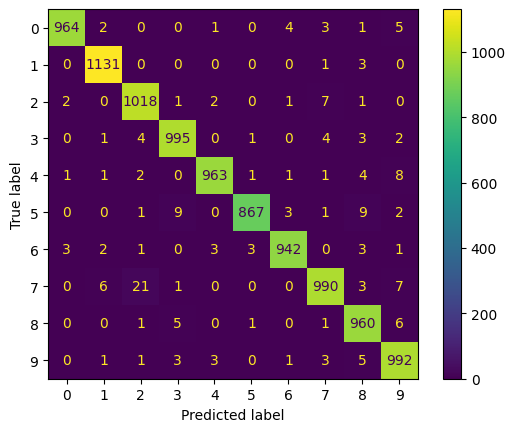

In [57]:
conf=confusion_matrix(y_test_labels,y_pred_labels)
con_plot=ConfusionMatrixDisplay(confusion_matrix=conf)
con_plot.plot()

In [58]:
from keras.models import load_model

model = load_model("best_model.keras")


for i in range(5):
    sample = X_test[i].reshape(1, 28, 28, 1)
    pred = model.predict(sample)
    print("Pred:", np.argmax(pred), " | True:", np.argmax(y_test[i])) #argmax returns the biggest porpability index

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Pred: 7  | True: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Pred: 2  | True: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Pred: 1  | True: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Pred: 0  | True: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Pred: 4  | True: 4
